# Building Grid

I am still doing this on a grid, but now with a better parameter choice. I have trimmed the number of print statements from the grid calculation.

In [1]:
#--LIBRARIES--------

import eelib
from eelib import pi

import numpy as np
import pickle
import pandas as pd
from sklearn.linear_model import LinearRegression

#plotting
import matplotlib.pyplot as plt
import seaborn as sns #statistical data visualization

In [2]:
#--PARAMETERS--------

# note that k, B, and R are percents here, mu is not as its scale is unknown
dk = 0.5
R  = 1.0
B  = 0.5
mu = 1.0e-7

n_dk = 8
n_m  = 8
n_g  = 15
#n_k0 = 3
#n_a = 1
n_b  = 8
#n_r  = 5

# 12 hrs?


b_r  = (0.03, 1.0) # B here is B*R, since varying R will alter k, which I don't want
dk_r = (0.1, 0.9)
mu_r = (-8, -5) #1.0e-8 to 1.0e-5

num_l = [n_m, n_dk, n_b, n_g]

#k0_r #later ....

# These two will not be varied, since they can be accomodated by a rescaling.
#a_r = 0.5
#r_r  = (0.5, 1.1)

pr = 200
n = 20

In [3]:
#--CODE--

#make loop, grid, or system
gridl = eelib.grid_fast_osc(R, B, dk, mu)

gridl.makeGridPoints(mu=mu_r, dk=dk_r,B=b_r,num = num_l)
gridl.gridFastOsc()

Begin grid build:  0.0
Number of periods to calculate: 115200
mu: 0, dk: 0, Time: 0.0
mu: 0, dk: 1, Time: 655.0664985179901
mu: 0, dk: 2, Time: 1271.7873320579529
mu: 0, dk: 3, Time: 1908.1545000076294
mu: 0, dk: 4, Time: 2539.546858072281
mu: 0, dk: 5, Time: 3173.1147198677063
mu: 0, dk: 6, Time: 3810.327386379242
mu: 0, dk: 7, Time: 4428.464920043945
mu: 1, dk: 0, Time: 5136.915075063705
mu: 1, dk: 1, Time: 5817.023308753967
mu: 1, dk: 2, Time: 6466.315454006195
mu: 1, dk: 3, Time: 7106.556745529175
mu: 1, dk: 4, Time: 7752.5775825977325
mu: 1, dk: 5, Time: 8391.220142364502
mu: 1, dk: 6, Time: 9000.382742643356
mu: 1, dk: 7, Time: 9621.473605394363
mu: 2, dk: 0, Time: 10244.339130401611
mu: 2, dk: 1, Time: 10877.669263362885
mu: 2, dk: 2, Time: 11510.688523769379
mu: 2, dk: 3, Time: 12126.834075689316
mu: 2, dk: 4, Time: 12773.171298742294
mu: 2, dk: 5, Time: 13396.720515012741
mu: 2, dk: 6, Time: 14010.441543579102
mu: 2, dk: 7, Time: 14628.293595552444
mu: 3, dk: 0, Time: 15249.16

In [4]:
# since this takes a while to run and is used for a while, it is best to save a copy of the data
file = open('grid002', 'ab')
pickle.dump(gridl, file)
file.close()

In [ ]:
#loading script; be careful of python version
#file = open('grid001', 'rb')    
#gridl = pickle.load(file)
#file.close()

# Defining variables for analysis

In [5]:
# Pull the grids of values from our object

# independent variables
B_g = gridl.mfs  # B (for B * R)
dk_g = gridl.ewd    # k
mu_g = gridl.nls   # mu
#amp = gridl.amp
dgrid = gridl.d0_grid

# dependent variables
fot = gridl.fast_osc_t[:,:,:,0,0,0,:,:]

fot0 = gridl.fast_osc_t_0[:,:,:,0,0,0,:,:]

In [6]:
dfot = np.copy(fot)
dfot0 = np.copy(fot0)
for ii, kk in enumerate(dk_g):
    dfot[:,ii,:,:,:] = fot[:,ii,:,:,:] - pi /(eelib.kFAu+kk/1e-6/2.0)
    dfot0[:,ii,:,:,:] = fot0[:,ii,:,:,:] - pi /(eelib.kFAu+kk/1e-6/2.0)

In [7]:
dgridk = np.zeros((n_dk,n_g,n_g), dtype=complex)
for ii, kk in enumerate(dk_g):
    dgridk[ii] = dgrid/(eelib.kFAu+kk/1e-6/2.0)

In [8]:
# This is the period of the fast oscillations of |psi|^2 without ee interaction
# Note that the actual period of the fast oscillations is twice this

t_1 = pi/(eelib.kFAu)
t_new  = pi/(gridl.l_calc.k)
#=eelib.pi/(eelib.kFAu+gridl.l_calc.M/4)


In [41]:
# Here we are changing the format of variable storage
# This is intended for use with pandas
# Columns are parameter / variable values here

size = np.shape(fot.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

sz = [n_dk*n_b*n_g**2, n_b*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ik in range(n_dk):
        for ib in range(n_b):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz[0]+ik*sz[1]+ib*sz[2]+idr*sz[3]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 1] = dk_g[ik]
                    npaf[ind, 2] = B_g[ib]
                    npaf[ind, 3] = np.real(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 4] = np.imag(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 5] = fot[imu, ik, ib, idr, idi]-(pi / (eelib.kFAu + dk_g[ik]/R /2.0))

115200


In [42]:
# now as a pandas dataframe
dfa = pd.DataFrame(npaf, columns = ["mu", "dk", "B", "D re", "D im", "T fast"])

# and to show it
dfa

,mu,dk,B,D re,D im,T fast
0,1.000000e-08,0.1,0.03,-1.380810,-1.38081,7.108685e-17
1,1.000000e-08,0.1,0.03,-1.321546,-1.38081,-8.440871e-18
2,1.000000e-08,0.1,0.03,-1.204153,-1.38081,-2.028408e-16
3,1.000000e-08,0.1,0.03,-1.033794,-1.38081,-3.451403e-16
4,1.000000e-08,0.1,0.03,-0.817964,-1.38081,-5.303773e-16
...,...,...,...,...,...,...
115195,1.000000e-05,0.9,1.00,0.817964,1.38081,1.319705e-12
115196,1.000000e-05,0.9,1.00,1.033794,1.38081,1.471241e-12
115197,1.000000e-05,0.9,1.00,1.204153,1.38081,1.616274e-12
115198,1.000000e-05,0.9,1.00,1.321546,1.38081,1.729485e-12


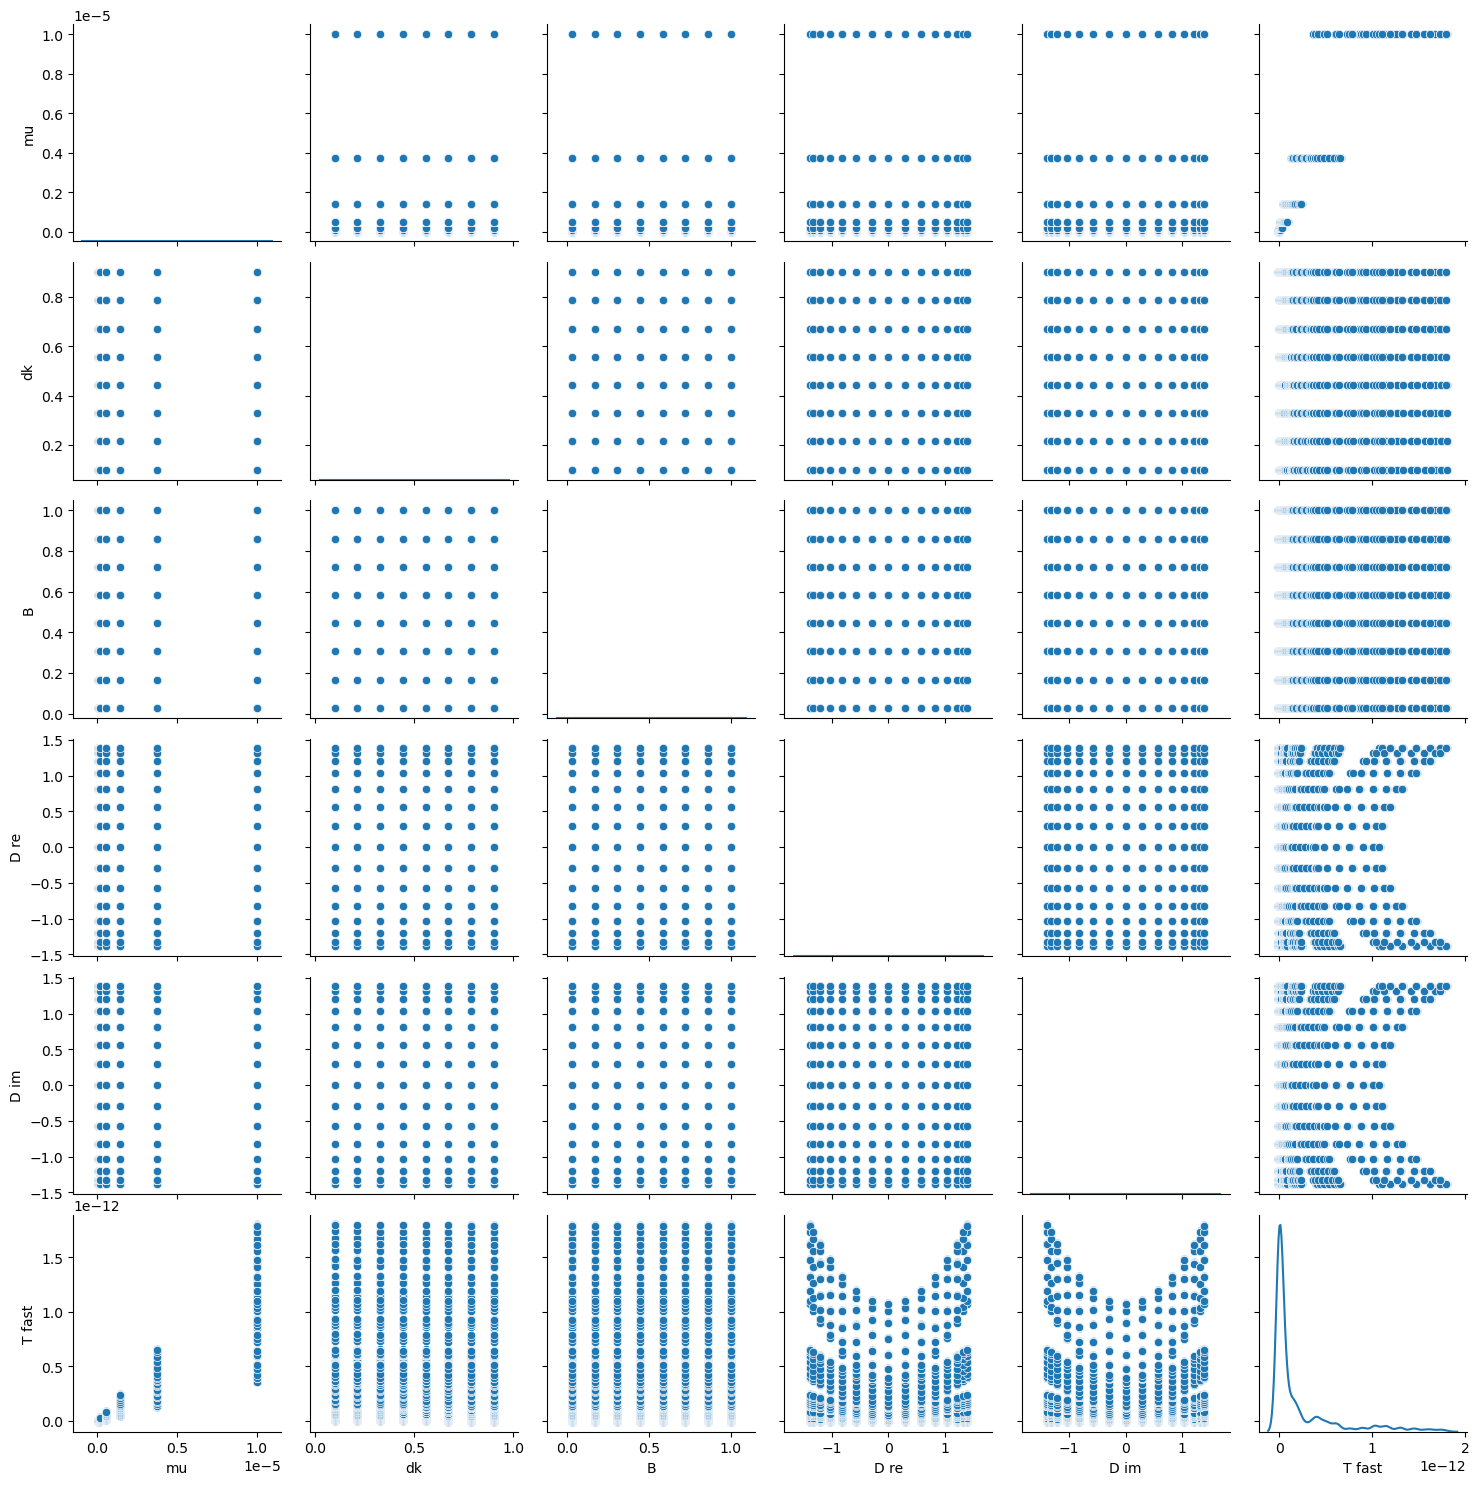

In [43]:
g = sns.PairGrid(dfa)
#g.map(sns.scatterplot)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
#g.map_diag(sns.kdeplot)

The expected pattern has appeared very clearly. I now need to fit the $\mu\left|\frac{\Psi^\prime}{k}\right|^2$ term. I will need to look at how dk influences $\Psi^\prime_0$ dependences later.

# $\mu$ linear regression fitting

Linear regression will proceed as before. I will fit $\mu^2$, $\mu$, and the intercept terms. $\mu$ should be primary, while $\mu^2$ and the intercept are the corrections. Corrections are important due to rapid oscillation.

I believe that the intercept term is due to a constant underestimating of the period, which exists even within the case without ee interaction. This error is small, but adds up over oscillations, and therefore needs to be properly modelled in order to match the two sides. Fortunately, we have the exact solution without ee interaction to aid in modelling. I also know that drop in amplitude for the ee interaction case is identical to that without, so the issue should be solvable.

Let us start with plotting. We need to change the variables in all of the code below. 

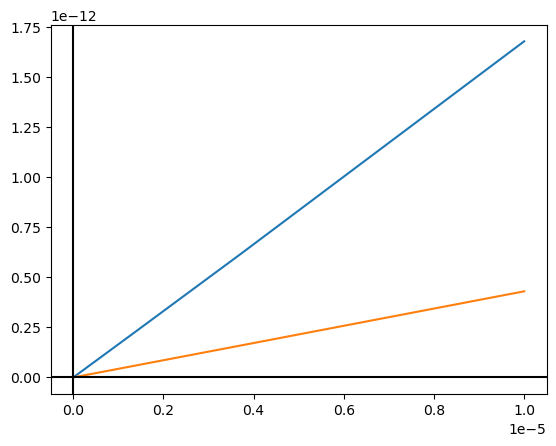

In [44]:
# for easy changing which two plots to use.

mui = []
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(mui), len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(mu_g, dfot[:, ki[i],bi[i],d1i[i],d2i[i]])
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

In [26]:
# 1% Error Tolerance

1/(1e-6/t_1) * pi/(eelib.kFAu + max(dk_g)/R /2.0) * 0.01

6.853891944943923e-16

We ideally want the error below $7 \times 10^{-16}$. Note that dk doesn't change this estimate at all.

And now regression.

In [45]:
slope = np.zeros((n_dk, n_b, n_g, n_g, 2))
intercept = np.zeros((n_dk, n_b, n_g, n_g))
r = 1.1    # for finding the minimum r value

for i in range(n_dk):
    for j in range(n_b):
        for k1 in range(n_g):
            for k2 in range(n_g):
                X = np.array([mu_g, np.power(mu_g,2)]).T
                y = dfot[:,i,j,k1,k2]

                reg = LinearRegression().fit(X, y)

                slope[i,j,k1,k2]=reg.coef_
                intercept[i,j,k1,k2]=reg.intercept_

                r2 = reg.score(X, y)
                r = min(r, r2)

                #print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0.9999999811500869


Not bad. A better fit than before.

In [47]:
np.min(dfot), np.max(dfot)

(-2.5061339710370244e-16, 1.8024813449445651e-12)

In [46]:
print(np.min(slope[:,:,:,:,0])*1e-6, np.max(slope[:,:,:,:,0])*1e-6)
print(np.min(slope[:,:,:,:,1])*1e-12, np.max(slope[:,:,:,:,1])*1e-12)
print(np.min(intercept), np.max(intercept))

3.674145048725801e-14 1.7695523194884252e-13
7.362217143096635e-18 3.3745010675670505e-16
-7.910990061590725e-16 -4.338195889677468e-16


# Visualization

In [48]:
slope_lin = slope[:,:,:,:,0]
slope_quad = slope[:,:,:,:,1]

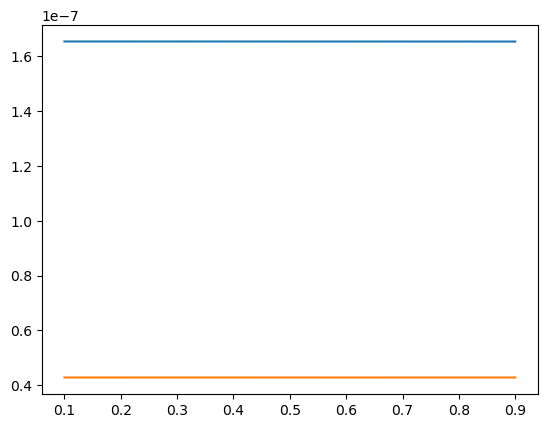

In [49]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(dk_g, slope_lin[:,bi[i],d1i[i],d2i[i]])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

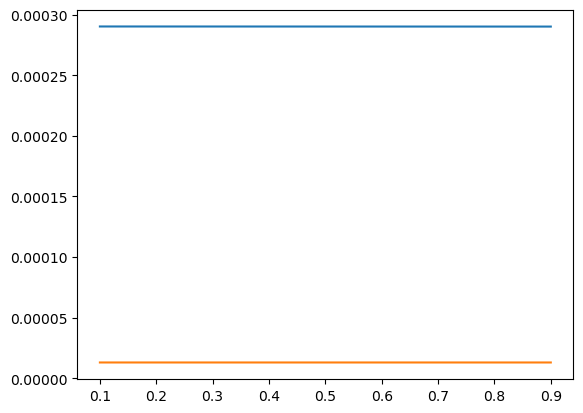

In [60]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(dk_g, slope_quad[:,bi[i],d1i[i],d2i[i]])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

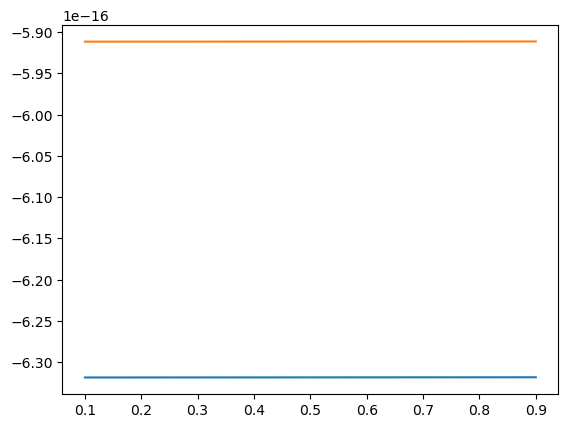

In [61]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(dk_g, intercept[:,bi[i],d1i[i],d2i[i]])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

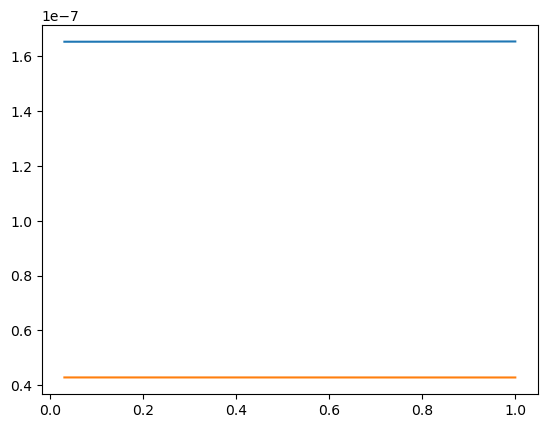

In [ ]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(B_g, slope_lin[ki[i],:,d1i[i],d2i[i]])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

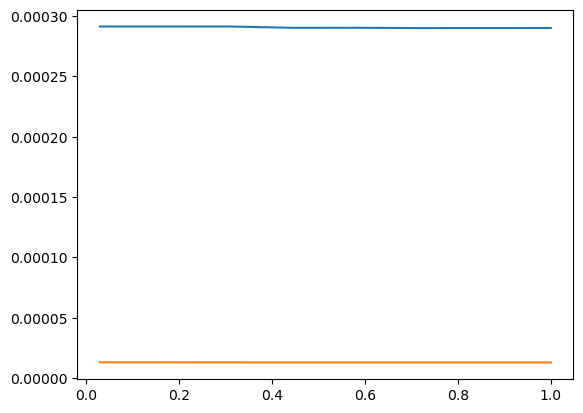

In [62]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(B_g, slope_quad[ki[i],:,d1i[i],d2i[i]])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

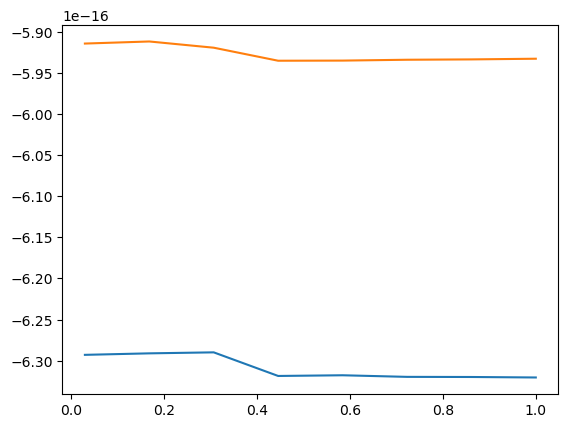

In [63]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(B_g, intercept[ki[i],:,d1i[i],d2i[i]])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

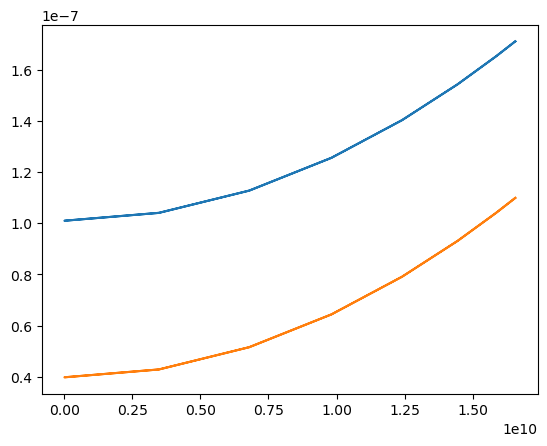

In [75]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.abs(np.real(dgrid[d1i[i],:])), slope_lin[ki[i],bi[i],d1i[i], :])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

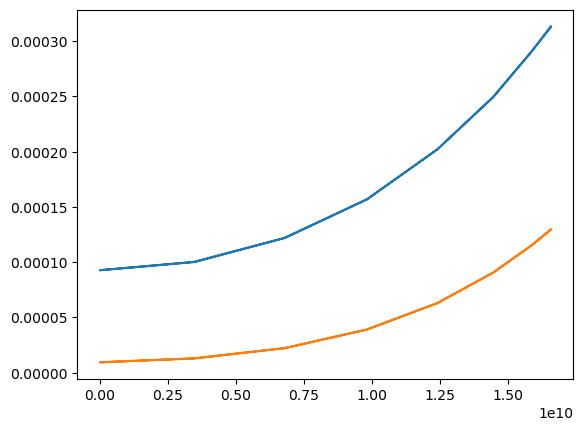

In [74]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.abs(np.real(dgrid[d1i[i],:])), slope_quad[ki[i],bi[i],d1i[i], :])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

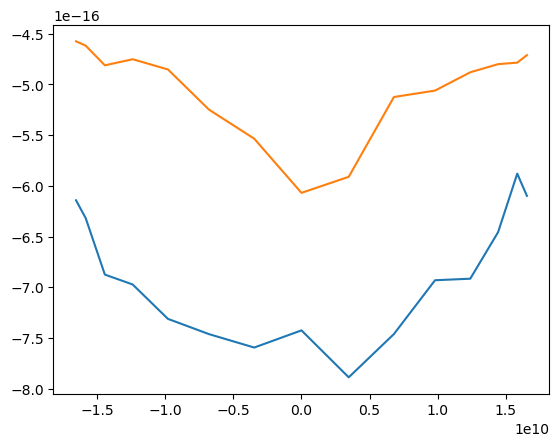

In [65]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.real(dgrid[d1i[i],:]), intercept[ki[i],bi[i],d1i[i], :])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

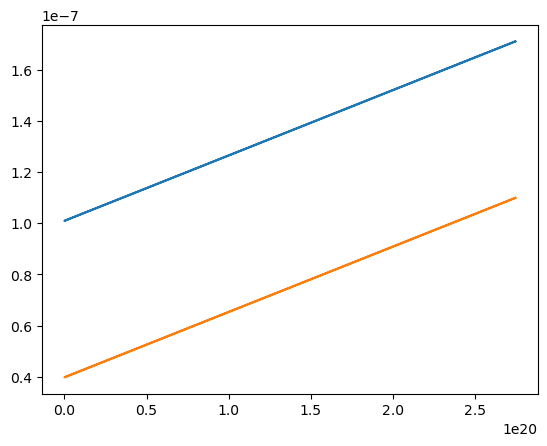

In [76]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.abs(np.imag(dgrid[:,d2i[i]])**2), slope_lin[ki[i],bi[i],:,d2i[i]])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

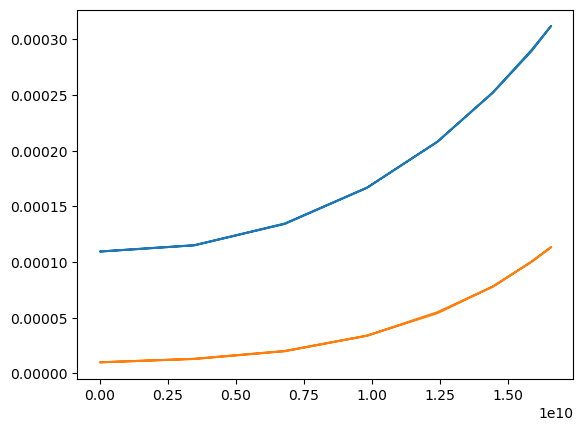

In [72]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.abs(np.imag(dgrid[:,d2i[i]])), slope_quad[ki[i],bi[i],:,d2i[i]])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

Quadratic and quartic terms of derivative.

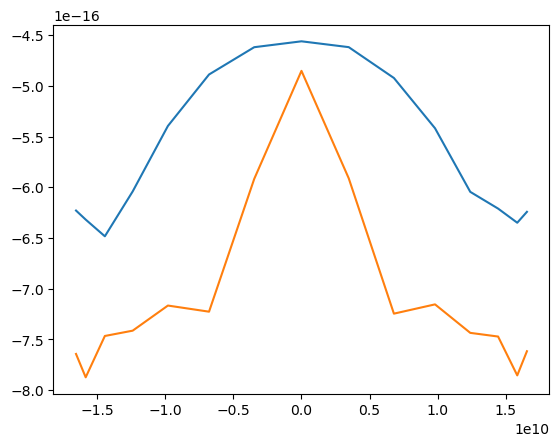

In [67]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.imag(dgrid[:,d2i[i]]), intercept[ki[i],bi[i],:,d2i[i]])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

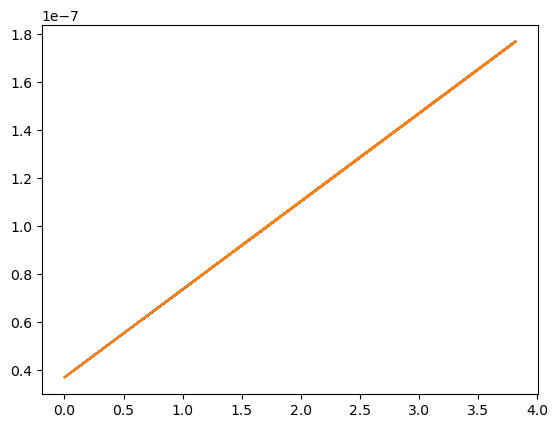

In [82]:
ki  = [2, 6]
bi  = [7, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.abs(dgridk[ki[i]].flatten())**2, slope_lin[ki[i],bi[i]].flatten())
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

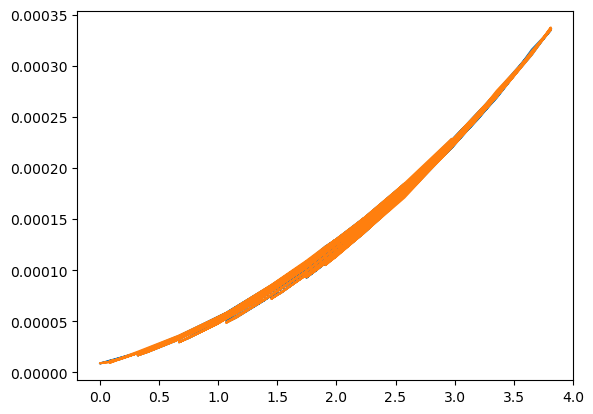

In [83]:
ki  = [2, 6]
bi  = [7, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.abs(dgridk[ki[i]].flatten())**2, slope_quad[ki[i],bi[i]].flatten())
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

# $\Psi^\prime_0$ Regression

**$\mu$ term**

In [175]:
slope_md = np.zeros((n_dk,n_b,3))
intercept_md = np.zeros((n_dk,n_b))
r = 1.1    # for finding the minimum r value


for ii in range(n_dk):
    for jj in range(n_b):
        X = np.array([np.imag(dgridk[ii].flatten()), np.imag(dgridk[ii].flatten())**2, np.real(dgridk[ii].flatten())**2]).T#, 
                      #np.real(dgridk[ii].flatten())**4, np.imag(dgridk[ii].flatten())**4, 
                      #np.real(dgridk[ii].flatten())**2*np.imag(dgridk[ii].flatten())**2]).T
        y = slope_lin[ii,jj].flatten()

        reg = LinearRegression().fit(X, y)

        slope_md[ii,jj]=reg.coef_
        intercept_md[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        #print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0.9999999705357292


In [176]:
print(np.min(slope_md[:,:,0])*1e-6, np.max(slope_md[:,:,0])*1e-6)
print(np.min(slope_md[:,:,1])*1e-6, np.max(slope_md[:,:,1])*1e-6)
print(np.min(slope_md[:,:,2])*1e-6, np.max(slope_md[:,:,2])*1e-6)
print(np.min(intercept_md)*1e-6, np.max(intercept_md)*1e-6)

-6.014767526429553e-17 -1.6213042142473349e-18
3.67398618551264e-14 3.674415084667032e-14
3.674136251695866e-14 3.6746135608550485e-14
3.6751997077570625e-14 3.6757569331473346e-14


In [89]:
print(np.min(slope_md[:,:,0])*1e-6, np.max(slope_md[:,:,0])*1e-6)
print(np.min(slope_md[:,:,1])*1e-6, np.max(slope_md[:,:,1])*1e-6)
print(np.min(intercept_md)*1e-6, np.max(intercept_md)*1e-6)

3.673986185512639e-14 3.67441508466703e-14
3.6741362516958636e-14 3.674613560855048e-14
3.675199707757065e-14 3.6757569331473346e-14


The higher order terms may be relevant, but the main terms here are for $|\Psi_0|^2$ and $|\Psi^\prime_0|^2$ as expected, and they are all very close to each other. Lets look at the correction terms for other orders of $\mu$ now, and get back to this later.

**$\mu^2$ Terms**

In [ ]:
slope_m2d = np.zeros((n_dk,n_b,5))
intercept_m2d = np.zeros((n_dk,n_b))
r = 1.1    # for finding the minimum r value


for ii in range(n_dk):
    for jj in range(n_b):
        X = np.array([np.imag(dgridk[ii].flatten())**2, np.real(dgridk[ii].flatten())**2, 
                      np.real(dgridk[ii].flatten())**4, np.imag(dgridk[ii].flatten())**4, 
                      np.real(dgridk[ii].flatten())**2*np.imag(dgridk[ii].flatten())**2]).T
        y = slope_quad[ii,jj].flatten()

        reg = LinearRegression().fit(X, y)

        slope_m2d[ii,jj]=reg.coef_
        intercept_m2d[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        #print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0.9999579781625512


In [96]:
print(np.min(slope_m2d[:,:,0])*1e-12, np.max(slope_m2d[:,:,0])*1e-12)
print(np.min(slope_m2d[:,:,1])*1e-12, np.max(slope_m2d[:,:,1])*1e-12)
print(np.min(slope_m2d[:,:,2])*1e-12, np.max(slope_m2d[:,:,2])*1e-12)
print(np.min(slope_m2d[:,:,3])*1e-12, np.max(slope_m2d[:,:,3])*1e-12)
print(np.min(slope_m2d[:,:,4])*1e-12, np.max(slope_m2d[:,:,4])*1e-12)
print(np.min(intercept_m2d)*1e-12, np.max(intercept_m2d)*1e-12)

2.022305715136432e-17 2.093495125245468e-17
2.896895266454488e-17 2.976030488772726e-17
1.580175803702972e-17 1.6147221536683383e-17
1.5753272740449302e-17 1.6082995212537846e-17
3.1680297787381744e-17 3.191290630821108e-17
8.304591428688e-18 8.76277780104023e-18


Relevant for greater $\mu$. The term linear in $\Im(\Psi^\prime_0)$ can be scrapped. 

**$\mu$ Intercept Terms**

In [99]:
slope_m0d = np.zeros((n_dk,n_b,3))
intercept_m0d = np.zeros((n_dk,n_b))
r = 1.1    # for finding the minimum r value


for ii in range(n_dk):
    for jj in range(n_b):
        X = np.array([np.imag(dgridk[ii].flatten())**2, np.real(dgridk[ii].flatten())**2, np.imag(dgridk[ii].flatten())**4]).T
        y = intercept[ii,jj].flatten()

        reg = LinearRegression().fit(X, y)

        slope_m0d[ii,jj]=reg.coef_
        intercept_m0d[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        #print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0.8889668609438391


Low R, but this is for the chaotic error, so that is expected.

In [100]:
print(np.min(slope_m0d[:,:,0]), np.max(slope_m0d[:,:,0]))
print(np.min(slope_m0d[:,:,1]), np.max(slope_m0d[:,:,1]))
print(np.min(slope_m0d[:,:,2]), np.max(slope_m0d[:,:,2]))
print(np.min(intercept_m0d), np.max(intercept_m0d))

-2.7900027660070157e-16 -2.7314016171726106e-16
8.037421840671574e-17 8.159247478809068e-17
9.038943480850812e-17 9.360968170538533e-17
-5.709848101147942e-16 -5.683666387493812e-16


Remove -- linear imag psi, real ^4, real^2*real^2 terms. The other terms are within our desired level of tolerance.

I need to save these terms for the $k$ and $B$ dependence terms. I am hoping all $k$ dependence has been removed within tolerance. I know $B$ has not, but is not in the leading order error. I should try to fit for orders of $\frac{M}{k}$, and see if that keeps me within model tolerance for error.

# $k$ and $M$ Regression for $\mu$ Linear Term

In [112]:
np.shape(slope_md)

(8, 8, 6)

In [177]:
slope_mk = np.zeros((4,n_b,4))
intercept_mk = np.zeros((4,n_b))
r = 1.1    # for finding the minimum r value


for ii in range(3):
    for jj in range(n_b):
        X = np.array([dk_g, dk_g**2, np.power(dk_g,2), np.exp(dk_g)]).T
        y = slope_md[:,jj,ii]

        reg = LinearRegression().fit(X, y)

        slope_mk[ii,jj]=reg.coef_
        intercept_mk[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        print(ii, jj, slope_mk[ii,jj], intercept_mk[ii,jj], r2)

ii = 3

for jj in range(n_b):
    X = np.array([dk_g, dk_g**2, np.power(dk_g,2), np.exp(dk_g)]).T
    y = intercept_md[:,jj]

    reg = LinearRegression().fit(X, y)

    slope_mk[ii,jj]=reg.coef_
    intercept_mk[ii,jj]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, jj, slope_mk[ii,jj], intercept_mk[ii,jj], r2)


print(r)

0 0 [-1.30187186e-12 -1.53825205e-12 -1.53825205e-12  2.61856698e-12] -4.519592895466107e-12 0.9413685871332972
0 1 [-7.36766462e-12 -3.42627501e-12 -3.42627501e-12  8.40851832e-12] -1.866813634815386e-11 0.702173868393245
0 2 [-1.18334793e-12 -5.74544099e-13 -5.74544099e-13  1.39378157e-12] -1.977387511121377e-11 0.4260406190227154
0 3 [ 6.02400107e-13  2.37041375e-13  2.37041375e-13 -6.29468440e-13] -2.5923619537239828e-11 0.6148131506793673
0 4 [-9.78040987e-13 -5.28738156e-13 -5.28738156e-13  1.18486720e-12] -3.626945510916955e-11 0.9783564931484655
0 5 [-1.04032232e-13 -9.63401150e-14 -9.63401150e-14  1.84977694e-13] -4.3973873910385086e-11 0.854618688584006
0 6 [ 1.05281460e-12  5.12515381e-13  5.12515381e-13 -1.21094758e-12] -5.058375339092453e-11 0.8601877685942995
0 7 [-1.03118413e-12 -1.83332077e-13 -1.83332077e-13  8.14408609e-13] -6.086073490822987e-11 0.655390063454963
1 0 [ 1.09035295e-11  5.73085401e-12  5.73085401e-12 -1.57492729e-11] 3.676034962366206e-08 0.99433343340

In [147]:
print(np.min(slope_mk[:,:,0])*1e-6, np.max(slope_mk[:,:,0])*1e-6)
print(np.min(slope_mk[:,:,1])*1e-6, np.max(slope_mk[:,:,1])*1e-6)
print(np.min(slope_mk[:,:,2])*1e-6, np.max(slope_mk[:,:,2])*1e-6)
print(np.min(slope_mk[:,:,3])*1e-6, np.max(slope_mk[:,:,3])*1e-6)
print(np.min(intercept_mk)*1e-6, np.max(intercept_mk)*1e-6)

-5.628450840242162e-17 3.6224843191058396e-17
-2.5750599074306116e-17 1.824021854649138e-17
-2.5750599074306172e-17 1.8240218546491407e-17
-4.1463319813620234e-17 6.08216851375509e-17
-6.086073490822691e-17 3.6790836170949125e-14


The fit is not very good, and appears to be around my error. The dominant term is in the intercept. I wanted to try $\frac{M}{k}$. 

0 -- chaotic
1 -- ~linear, chaotic for low B
2 -- ~linear
3 -- chaotic
4 -- chaotic
5 -- chaotic
intercept -- known dependence visible.

**B Dependence**

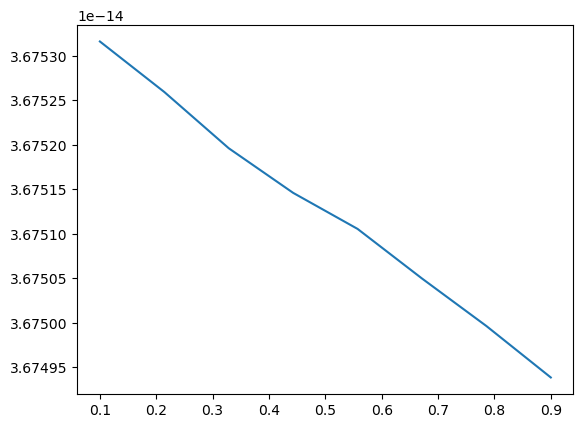

In [144]:
bi = [3]
dt = [5]

ilim = 1

fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(dk_g, intercept_md[:,bi[i]]*1e-6)
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

In [148]:
M_g = B_g*1e-6*eelib.phi0inv

In [154]:
M_g[:]/(eelib.kFAu+dk_g[0]/1e-6/2)

array([0.00189908, 0.010671  , 0.01944293, 0.02821485, 0.03698677,
       0.0457587 , 0.05453062, 0.06330255])

In [155]:
M_g[:]/(eelib.kFAu+dk_g[7]/1e-6/2)

array([0.00189901, 0.01067065, 0.01944228, 0.02821391, 0.03698554,
       0.04575717, 0.0545288 , 0.06330044])

In [ ]:
M_k = np.zeros((n_b,n_dk))
for ii in range(n_b):
    for jj in range(n_dk):
        M_k[ii,jj] = M_g[ii]/(eelib.kFAu+dk_g[jj]/1e-6/2)

M_k

array([[0.00189908, 0.00189907, 0.00189906, 0.00189905, 0.00189904,
        0.00189903, 0.00189902, 0.00189901],
       [0.010671  , 0.01067095, 0.0106709 , 0.01067085, 0.0106708 ,
        0.01067075, 0.0106707 , 0.01067065],
       [0.01944293, 0.01944283, 0.01944274, 0.01944265, 0.01944255,
        0.01944246, 0.01944237, 0.01944228],
       [0.02821485, 0.02821471, 0.02821458, 0.02821445, 0.02821431,
        0.02821418, 0.02821404, 0.02821391],
       [0.03698677, 0.0369866 , 0.03698642, 0.03698625, 0.03698607,
        0.03698589, 0.03698572, 0.03698554],
       [0.0457587 , 0.04575848, 0.04575826, 0.04575804, 0.04575783,
        0.04575761, 0.04575739, 0.04575717],
       [0.05453062, 0.05453036, 0.0545301 , 0.05452984, 0.05452958,
        0.05452932, 0.05452906, 0.0545288 ],
       [0.06330255, 0.06330225, 0.06330194, 0.06330164, 0.06330134,
        0.06330104, 0.06330074, 0.06330044]])

In [164]:
M_k**2

array([[3.60649116e-06, 3.60645681e-06, 3.60642247e-06, 3.60638812e-06,
        3.60635378e-06, 3.60631943e-06, 3.60628509e-06, 3.60625074e-06],
       [1.13870256e-04, 1.13869172e-04, 1.13868087e-04, 1.13867003e-04,
        1.13865918e-04, 1.13864834e-04, 1.13863750e-04, 1.13862665e-04],
       [3.78027333e-04, 3.78023733e-04, 3.78020133e-04, 3.78016533e-04,
        3.78012933e-04, 3.78009333e-04, 3.78005733e-04, 3.78002133e-04],
       [7.96077723e-04, 7.96070141e-04, 7.96062559e-04, 7.96054978e-04,
        7.96047397e-04, 7.96039816e-04, 7.96032235e-04, 7.96024654e-04],
       [1.36802142e-03, 1.36800840e-03, 1.36799537e-03, 1.36798234e-03,
        1.36796931e-03, 1.36795628e-03, 1.36794326e-03, 1.36793023e-03],
       [2.09385844e-03, 2.09383850e-03, 2.09381856e-03, 2.09379861e-03,
        2.09377867e-03, 2.09375873e-03, 2.09373879e-03, 2.09371885e-03],
       [2.97358876e-03, 2.97356044e-03, 2.97353213e-03, 2.97350381e-03,
        2.97347549e-03, 2.97344717e-03, 2.97341885e-03, 2.

In [178]:
slope_mM = np.zeros((4))
intercept_mM = np.zeros((4))
r = 1.1    # for finding the minimum r value


for ii in range(3):
    X = np.array([M_k.T.flatten()]).T
    y = slope_md[:,:,ii].flatten()

    reg = LinearRegression().fit(X, y)

    slope_mM[ii]=reg.coef_[0]
    intercept_mM[ii]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, slope_mM[ii], intercept_mM[ii], r2)

ii = 3

X = np.array([M_k.T.flatten()]).T
y = intercept_md[:,:].flatten()

reg = LinearRegression().fit(X, y)

slope_mM[ii]=reg.coef_[0]
intercept_mM[ii]=reg.intercept_

r2 = reg.score(X, y)
r = min(r, r2)

print(ii, slope_mM[ii], intercept_mM[ii], r2)


print(r)

0 -9.523875302486662e-10 1.0797810302275002e-13 0.9999405002818104
1 -9.115586309894051e-12 3.674230161486211e-08 0.02272764088589785
2 1.1985522511461173e-11 3.674325981229879e-08 0.036063591915900584
3 -1.1758373438325586e-11 3.6755324481870014e-08 0.030524784243045833
0.02272764088589785


M fitting doesn't help, except for the linear imag term. These terms seem to help get the main signal closer to a uniform slope (if considered necessary), but for the quartic terms, there is no point. I want to see if I can just ignore this fitting for other terms in the model.

In [179]:
X = np.array([M_k.T.flatten()]).T
y = slope_md[:,:,0].flatten()

reg = LinearRegression(fit_intercept=False).fit(X, y)

slope_mMi=reg.coef_[0]
intercept_mMi=reg.intercept_

r2 = reg.score(X, y)

print(slope_mMi*1e-6*0.05, r2)

-4.749937809412196e-17 0.9999317369996303


In [182]:
intercept_mM = np.zeros((3))
r = 1.1    # for finding the minimum r value


for ii in range(1,3):
    intercept_mM[ii-1]=np.average(slope_md[:,:,ii])

    print(intercept_mM[ii-1]*1e-6)

ii = 2

intercept_mM[ii]=np.average(intercept_md[:,:])

print(intercept_mM[ii]*1e-6)

3.674200444430406e-14
3.674365054354659e-14
3.6754941155742904e-14


Quartic terms appear unnecessary here. Lets go back to the $k$ dependence.

In [183]:
k_arr = np.zeros((n_dk, n_b))
for ii in range(n_dk):
    for jj in range(n_b):
        k_arr[ii,jj]=dk_g[ii]

In [184]:
k_arr = k_arr.flatten()

In [200]:
slope_mk = np.zeros((4,2))
intercept_mk = np.zeros((4))
r = 1.1    # for finding the minimum r value


for ii in range(3):
    X = np.array([k_arr, k_arr**2]).T
    y = slope_md[:,:,ii].flatten()

    reg = LinearRegression().fit(X, y)

    slope_mk[ii]=reg.coef_
    intercept_mk[ii]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, slope_mk[ii]*1e-6, intercept_mk[ii]*1e-6, r2)

ii = 3

X = np.array([k_arr, k_arr**2]).T
y = intercept_md.flatten()

reg = LinearRegression().fit(X, y)

slope_mk[ii]=reg.coef_
intercept_mk[ii]=reg.intercept_

r2 = reg.score(X, y)
r = min(r, r2)

print(ii, slope_mk[ii]*1e-6, intercept_mk[ii]*1e-6, r2)


print(r)

0 [ 6.14176827e-20 -6.57390684e-20] -3.0949877018904074e-17 4.57465424430481e-08
1 [-3.83686784e-18 -6.53954363e-19] 3.6744131209402115e-14 0.937403043250955
2 [-5.16664202e-18  4.96262484e-19] 3.674607576950877e-14 0.9300881472904924
3 [-5.01963765e-18  3.58580208e-19] 3.675733674116089e-14 0.8144602631425454
4.57465424430481e-08


There is little evidence of any dependence. Everything is within error. Ok. Lets put together this mess.

In [201]:
consts = {}

In [202]:
consts["mA2"] = intercept_mM[2]
consts["mDIM"] = slope_mMi
consts["mDI2"] = intercept_mM[0]
consts["mDR2"] = intercept_mM[1]

In [203]:
consts

{'mA2': 3.675494115574291e-08,
 'mDIM': -9.499875618824391e-10,
 'mDI2': 3.674200444430406e-08,
 'mDR2': 3.674365054354659e-08}

So far, first correction has 3 terms, and the second correction has one so far. The first correction is a reasonably simple model here, with one fitted parameter. The parameters only split around the point of my second correction. The second correction will be frustrating, however, and I don't know which terms are error. The $\mu$ intercept terms are definitely error. I will need to compare these to the numerical model without ee interaction.

# $k$ and $M$ Regression for $\mu^2$ Term

In [213]:
np.shape(slope_m2d)

(8, 8, 5)

Like before.

**k dependency terms**

In [215]:
slope_m2k = np.zeros((6,n_b,2))
intercept_m2k = np.zeros((6,n_b))
r = 1.1    # for finding the minimum r value


for ii in range(5):
    for jj in range(n_b):
        X = np.array([np.power(dk_g,1), np.power(dk_g,2)]).T
        y = slope_m2d[:,jj,ii]

        reg = LinearRegression().fit(X, y)

        slope_m2k[ii,jj]=reg.coef_
        intercept_m2k[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        print(ii, jj, slope_m2k[ii,jj]*1e-10, intercept_m2k[ii,jj]*1e-10, r2)

ii = 5

for jj in range(n_b):
    X = np.array([np.power(dk_g,1), np.power(dk_g,2)]).T
    y = intercept_m2d[:,jj]

    reg = LinearRegression().fit(X, y)

    slope_m2k[ii,jj]=reg.coef_
    intercept_m2k[ii,jj]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, jj, slope_m2k[ii,jj]*1e-10, intercept_m2k[ii,jj]*1e-10, r2)


print(r)

0 0 [-4.97996421e-17  2.24301983e-17] 2.0955154027310095e-15 0.6536039094575625
0 1 [ 2.80469691e-18 -5.40151144e-18] 2.051605739737058e-15 0.0938648664119458
0 2 [-1.31803468e-17  1.06114966e-17] 2.072782573185859e-15 0.19410759156219792
0 3 [-2.5889114e-17  2.0313896e-17] 2.0807873064796886e-15 0.3398702825538693
0 4 [ 5.49412023e-19 -1.11231873e-17] 2.02984605928466e-15 0.8157369846938615
0 5 [-4.15140990e-18  6.30358811e-18] 2.0411433506012414e-15 0.7118758475735738
0 6 [ 3.10548639e-18 -6.20268053e-18] 2.0543859261560344e-15 0.6587598297892493
0 7 [-4.92170697e-17  4.06165489e-17] 2.062009754041156e-15 0.8222713619657356
1 0 [ 5.59836380e-17 -4.54991101e-17] 2.955052886265664e-15 0.799491539736805
1 1 [ 1.59342222e-17 -9.01200540e-18] 2.9386904000764252e-15 0.6458169379913377
1 2 [ 7.37230593e-18 -1.51799949e-17] 2.9743105941802724e-15 0.7564172088362724
1 3 [5.73032753e-18 1.51735676e-18] 2.9407290134716066e-15 0.8426005702217423
1 4 [-1.39309211e-17  1.34228758e-17] 2.9082347644

Nothing at our order, poor convergence, ... In theory I could claim something existed, but it seems unnecessary.

In [218]:
slope_m2M = np.zeros((6,2))
intercept_m2M = np.zeros((6))
r = 1.1    # for finding the minimum r value


for ii in range(5):
    X = np.array([M_k.T.flatten(), M_k.T.flatten()**2]).T
    y = slope_m2d[:,:,ii].flatten()

    reg = LinearRegression().fit(X, y)

    slope_m2M[ii]=reg.coef_[0]
    intercept_m2M[ii]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, slope_m2M[ii]*1e-10*0.06, intercept_m2M[ii]*1e-10, r2)

ii = 5

X = np.array([M_k.T.flatten()]).T
y = intercept_m2d[:,:].flatten()

reg = LinearRegression().fit(X, y)

slope_m2M[ii]=reg.coef_[0]
intercept_m2M[ii]=reg.intercept_

r2 = reg.score(X, y)
r = min(r, r2)

print(ii, slope_m2M[ii]*1e-10*0.06, intercept_m2M[ii]*1e-10, r2)


print(r)

0 [-7.54936033e-17 -7.54936033e-17] 2.077844534341095e-15 0.32731945012420627
1 [-5.57809655e-17 -5.57809655e-17] 2.968487913445464e-15 0.6727795684037625
2 [3.86383798e-17 3.86383798e-17] 1.5829064017782416e-15 0.5647254392767549
3 [5.26301449e-17 5.26301449e-17] 1.5785468639316267e-15 0.4597033195434912
4 [-9.27278173e-18 -9.27278173e-18] 3.1808532960777826e-15 0.2616124065862706
5 [3.2511521e-17 3.2511521e-17] 8.345576199757135e-16 0.5596244300451372
0.2616124065862706


Nothing. 

In [221]:
ave_c_m2d = np.zeros((6))
for i in range(5):
    ave_c_m2d[i] = np.average(slope_m2d[:,:,i])
ave_c_m2d[5] = np.average(intercept_m2d)
print(ave_c_m2d*1e-10)

[2.05561148e-15 2.93585975e-15 1.59820712e-15 1.59105779e-15
 3.18235870e-15 8.52222358e-16]


These are only relevant for the largest $\mu$ values, which are likely unimportant. I will save them anyway.

In [222]:
consts["m2"] = ave_c_m2d[5]
consts["m2DI2"] = ave_c_m2d[0]
consts["m2DR2"] = ave_c_m2d[1]
consts["m2DR4"] = ave_c_m2d[2]
consts["m2DI4"] = ave_c_m2d[3]
consts["m2DI2R2"] = ave_c_m2d[4]

In [223]:
consts

{'mA2': 3.675494115574291e-08,
 'mDIM': -9.499875618824391e-10,
 'mDI2': 3.674200444430406e-08,
 'mDR2': 3.674365054354659e-08,
 'm2': 8.522223583430349e-06,
 'm2DI2': 2.0556114758548036e-05,
 'm2DR2': 2.9358597545134476e-05,
 'm2DR4': 1.598207117609667e-05,
 'm2DI4': 1.5910577914323505e-05,
 'm2DI2R2': 3.182358695140475e-05}

# $k$ and $M$ Regression for $\mu$ Intercept Term

In [225]:
slope_m0k = np.zeros((4,n_b,2))
intercept_m0k = np.zeros((4,n_b))
r = 1.1    # for finding the minimum r value


for ii in range(3):
    for jj in range(n_b):
        X = np.array([np.sin(pi*dk_g), np.cos(pi*dk_g)]).T
        y = slope_m0d[:,jj,ii]

        reg = LinearRegression().fit(X, y)

        slope_m0k[ii,jj]=reg.coef_
        intercept_m0k[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        print(ii, jj, slope_m0k[ii,jj], intercept_m0k[ii,jj], r2)

ii = 3

for jj in range(n_b):
    X = np.array([np.sin(pi*dk_g), np.cos(pi*dk_g)]).T
    y = intercept_m0d[:,jj]

    reg = LinearRegression().fit(X, y)

    slope_m0k[ii,jj]=reg.coef_
    intercept_m0k[ii,jj]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, jj, slope_m0k[ii,jj], intercept_m0k[ii,jj], r2)


print(r)

0 0 [-1.75157013e-18  5.90869215e-19] -2.757122527641111e-16 0.6810883966910385
0 1 [-1.14451282e-18 -3.09946952e-20] -2.7475665086031333e-16 0.3569503203165908
0 2 [-1.39000980e-18 -6.13896064e-19] -2.737129149998444e-16 0.3828245942765759
0 3 [-2.00127428e-18 -2.41661820e-19] -2.7522578237656255e-16 0.7540739651986659
0 4 [5.55825229e-19 4.13226292e-19] -2.7888480457149374e-16 0.7487652850333633
0 5 [-4.45663652e-19  1.17545496e-19] -2.76472865382808e-16 0.16292070036167594
0 6 [1.30439534e-18 2.84534795e-19] -2.765885279487947e-16 0.8352064590920366
0 7 [-4.30345399e-19 -3.69897931e-19] -2.744282009810987e-16 0.8719342017977375
1 0 [ 2.44634972e-19 -4.58040316e-20] 8.041514825047796e-17 0.42563347265454987
1 1 [7.58183440e-20 9.59226065e-20] 8.067433829173884e-17 0.806361544241831
1 2 [3.28147942e-19 5.77134205e-20] 8.104829947468711e-17 0.4420869865032089
1 3 [4.70257470e-19 5.70176003e-20] 8.070204815706324e-17 0.8721887717442938
1 4 [-1.07219077e-19 -1.01864257e-19] 8.15560332241

Nothing.

In [227]:
slope_m0M = np.zeros((4,2))
intercept_m0M = np.zeros((4))
r = 1.1    # for finding the minimum r value


for ii in range(3):
    X = np.array([M_k.T.flatten(), M_k.T.flatten()**2]).T
    y = slope_m0d[:,:,ii].flatten()

    reg = LinearRegression().fit(X, y)

    slope_m0M[ii]=reg.coef_[0]
    intercept_m0M[ii]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, slope_m0M[ii]*0.06, intercept_m2M[ii], r2)

ii = 3

X = np.array([M_k.T.flatten()]).T
y = intercept_m0d[:,:].flatten()

reg = LinearRegression().fit(X, y)

slope_m0M[ii]=reg.coef_[0]
intercept_m0M[ii]=reg.intercept_

r2 = reg.score(X, y)
r = min(r, r2)

print(ii, slope_m0M[ii]*0.06, intercept_m0M[ii], r2)


print(r)

0 [-4.65201631e-18 -4.65201631e-18] 2.077844534341095e-05 0.14345076580073834
1 [3.18608464e-18 3.18608464e-18] 2.9684879134454636e-05 0.7400688929470078
2 [5.5400165e-18 5.5400165e-18] 1.5829064017782415e-05 0.38115356006574186
3 [-6.20169984e-20 -6.20169984e-20] -5.697027686587538e-16 0.001614295292520218
0.001614295292520218


Nothing again.

        X = np.array([np.imag(dgridk[ii].flatten())**2, np.real(dgridk[ii].flatten())**2, np.imag(dgridk[ii].flatten())**4]).T


In [228]:
consts["intercept"] = np.average(intercept_m0d)
consts["DI2"] = np.average(slope_m0d[:,:,0])
consts["DR2"] = np.average(slope_m0d[:,:,1])
consts["DI4"] = np.average(slope_m0d[:,:,2])

In [229]:
consts

{'mA2': 3.675494115574291e-08,
 'mDIM': -9.499875618824391e-10,
 'mDI2': 3.674200444430406e-08,
 'mDR2': 3.674365054354659e-08,
 'm2': 8.522223583430349e-06,
 'm2DI2': 2.0556114758548036e-05,
 'm2DR2': 2.9358597545134476e-05,
 'm2DR4': 1.598207117609667e-05,
 'm2DI4': 1.5910577914323505e-05,
 'm2DI2R2': 3.182358695140475e-05,
 'intercept': -5.697364648383741e-16,
 'DI2': -2.7618261397447087e-16,
 'DR2': 8.0960114314636e-17,
 'DI4': 9.19298181818588e-17}

Ok. Now to test the model. (And compare to the old model from the other grid.)

# Model Testing

In [237]:
np.shape(dgridk)

(8, 15, 15)

In [16]:
consts = eelib.k_M_models.const_dic_001

In [232]:
dgrid_n = dgrid * t_new / eelib.pi

In [24]:
t_pred = np.zeros((n_m, n_dk, n_b, n_g, n_g))

for mm in range(n_m): 
    for kk in range(n_dk):
        for nn in range (n_b):
            for ii in range(n_g):
                for jj in range(n_g):
                    # constant terms -- t_0 and intercept (error)
                    t_pred[mm,kk,nn,ii,jj] = pi /(eelib.kFAu+dk_g[kk]/1e-6/2.0) + consts['intercept']
                    # terms independent of mu (error)
                    #t_pred[mm,kk,nn,ii,jj] += (np.real(dgridk[kk,ii,jj])**2 * consts['DR2'] 
                    #                         + np.imag(dgridk[kk,ii,jj])**2 * consts['DI2'] 
                    #                         + np.imag(dgridk[kk,ii,jj])**4 * consts['DI4'])

                    # mu linear terms
                    t_pred[mm,kk,nn,ii,jj] += mu_g[mm]*(consts['mDR2'] * np.real(dgridk[kk,ii,jj])**2
                                                      + consts['mDI2'] * np.imag(dgridk[kk,ii,jj])**2
                                                      + consts['mA2'])
                                                      #+ consts['mDIM'] * np.imag(dgridk[kk,ii,jj]) * B_g[nn])

                    # mu quadradic terms
                    #t_pred[mm,kk,nn,ii,jj] += mu_g[nn]**2*(consts['m2']
                    #        + consts['m2DI2'] * np.imag(dgridk[kk,ii,jj])**2
                    #        + consts['m2DR2'] * np.real(dgridk[kk,ii,jj])**2 
                    #        + consts['m2DR4'] * np.real(dgridk[kk,ii,jj])**4 
                    #        + consts['m2DI4'] * np.imag(dgridk[kk,ii,jj])**4
                    #        + consts['m2DI2R2'] * np.real(dgridk[kk,ii,jj])**2 * np.imag(dgridk[kk,ii,jj])**2)
                    

In [252]:
np.max(fot-t_pred), np.min(fot-t_pred)

(3.4409606539649355e-14, -2.2994415196096463e-16)

In [17]:
t_pred = np.zeros((n_m, n_dk, n_b, n_g, n_g))

for mm in range(n_m): 
    for kk in range(n_dk):
        for nn in range (n_b):
            for ii in range(n_g):
                for jj in range(n_g):
                    # constant terms -- t_0 and intercept (error)
                    t_pred[mm,kk,nn,ii,jj] = pi /(eelib.kFAu+dk_g[kk]/1e-6/2.0) + consts['intercept']
                    # terms independent of mu (error)
                    t_pred[mm,kk,nn,ii,jj] += (np.real(dgridk[kk,ii,jj])**2 * consts['DR2'] 
                                             + np.imag(dgridk[kk,ii,jj])**2 * consts['DI2'] 
                                             + np.imag(dgridk[kk,ii,jj])**4 * consts['DI4'])

                    # mu linear terms
                    t_pred[mm,kk,nn,ii,jj] += mu_g[mm]*(consts['mDR2'] * np.real(dgridk[kk,ii,jj])**2
                                                      + consts['mDI2'] * np.imag(dgridk[kk,ii,jj])**2
                                                      + consts['mA2']
                                                      + consts['mDIM'] * np.imag(dgridk[kk,ii,jj]) * B_g[nn])

                    # mu quadradic terms
                    t_pred[mm,kk,nn,ii,jj] += mu_g[mm]**2*(consts['m2']
                            + consts['m2DI2'] * np.imag(dgridk[kk,ii,jj])**2
                            + consts['m2DR2'] * np.real(dgridk[kk,ii,jj])**2 
                            + consts['m2DR4'] * np.real(dgridk[kk,ii,jj])**4 
                            + consts['m2DI4'] * np.imag(dgridk[kk,ii,jj])**4
                            + consts['m2DI2R2'] * np.real(dgridk[kk,ii,jj])**2 * np.imag(dgridk[kk,ii,jj])**2)

In [302]:
np.max(fot-t_pred), np.min(fot-t_pred)

(1.3048743241978739e-16, -1.6540096097562107e-16)

In [261]:
mu_g

array([1.00000000e-08, 2.68269580e-08, 7.19685673e-08, 1.93069773e-07,
       5.17947468e-07, 1.38949549e-06, 3.72759372e-06, 1.00000000e-05])

In [18]:
size = np.shape(fot.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

sz = [n_dk*n_b*n_g**2, n_b*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ik in range(n_dk):
        for ib in range(n_b):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz[0]+ik*sz[1]+ib*sz[2]+idr*sz[3]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 1] = dk_g[ik]
                    npaf[ind, 2] = B_g[ib]
                    npaf[ind, 3] = np.real(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 4] = np.imag(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 5] = fot[imu, ik, ib, idr, idi]-t_pred[imu, ik, ib, idr, idi]

115200


In [19]:
dfa = pd.DataFrame(npaf, columns = ["mu", "dk", "B", "D re", "D im", "T fast"])

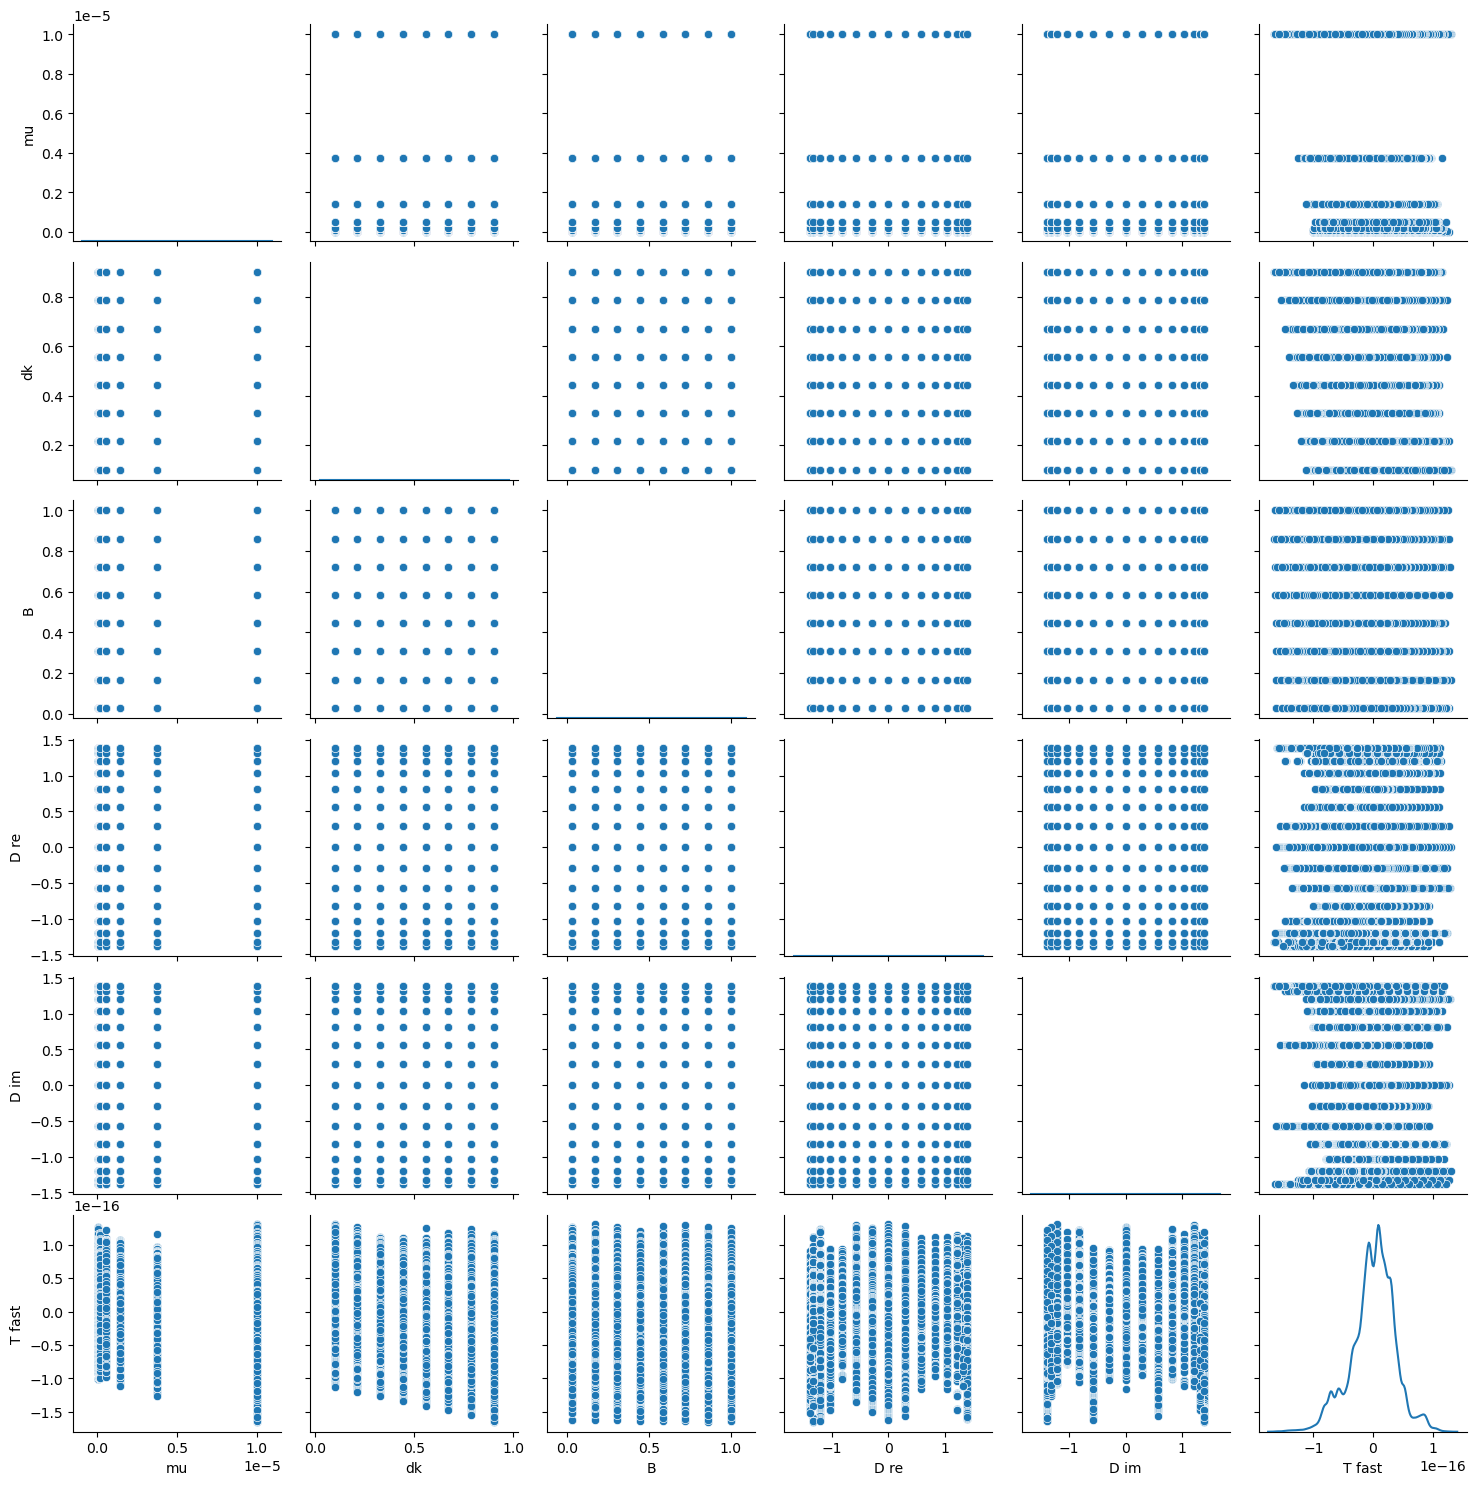

In [20]:
g = sns.PairGrid(dfa)
#g.map(sns.scatterplot)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
#g.map_diag(sns.kdeplot)

There are signals here, but I hope that we are already within tolerance. Linear, quadratic, and quartic terms are visible. Taylor expansion approximations work great here. 

# Without ee interaction

In [21]:
size = np.shape(fot.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

sz = [n_dk*n_b*n_g**2, n_b*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ik in range(n_dk):
        for ib in range(n_b):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz[0]+ik*sz[1]+ib*sz[2]+idr*sz[3]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 1] = dk_g[ik]
                    npaf[ind, 2] = B_g[ib]
                    npaf[ind, 3] = np.real(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 4] = np.imag(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 5] = dfot0[imu, ik, ib, idr, idi]

115200


In [22]:
dfa = pd.DataFrame(npaf, columns = ["mu", "dk", "B", "D re", "D im", "T fast"])

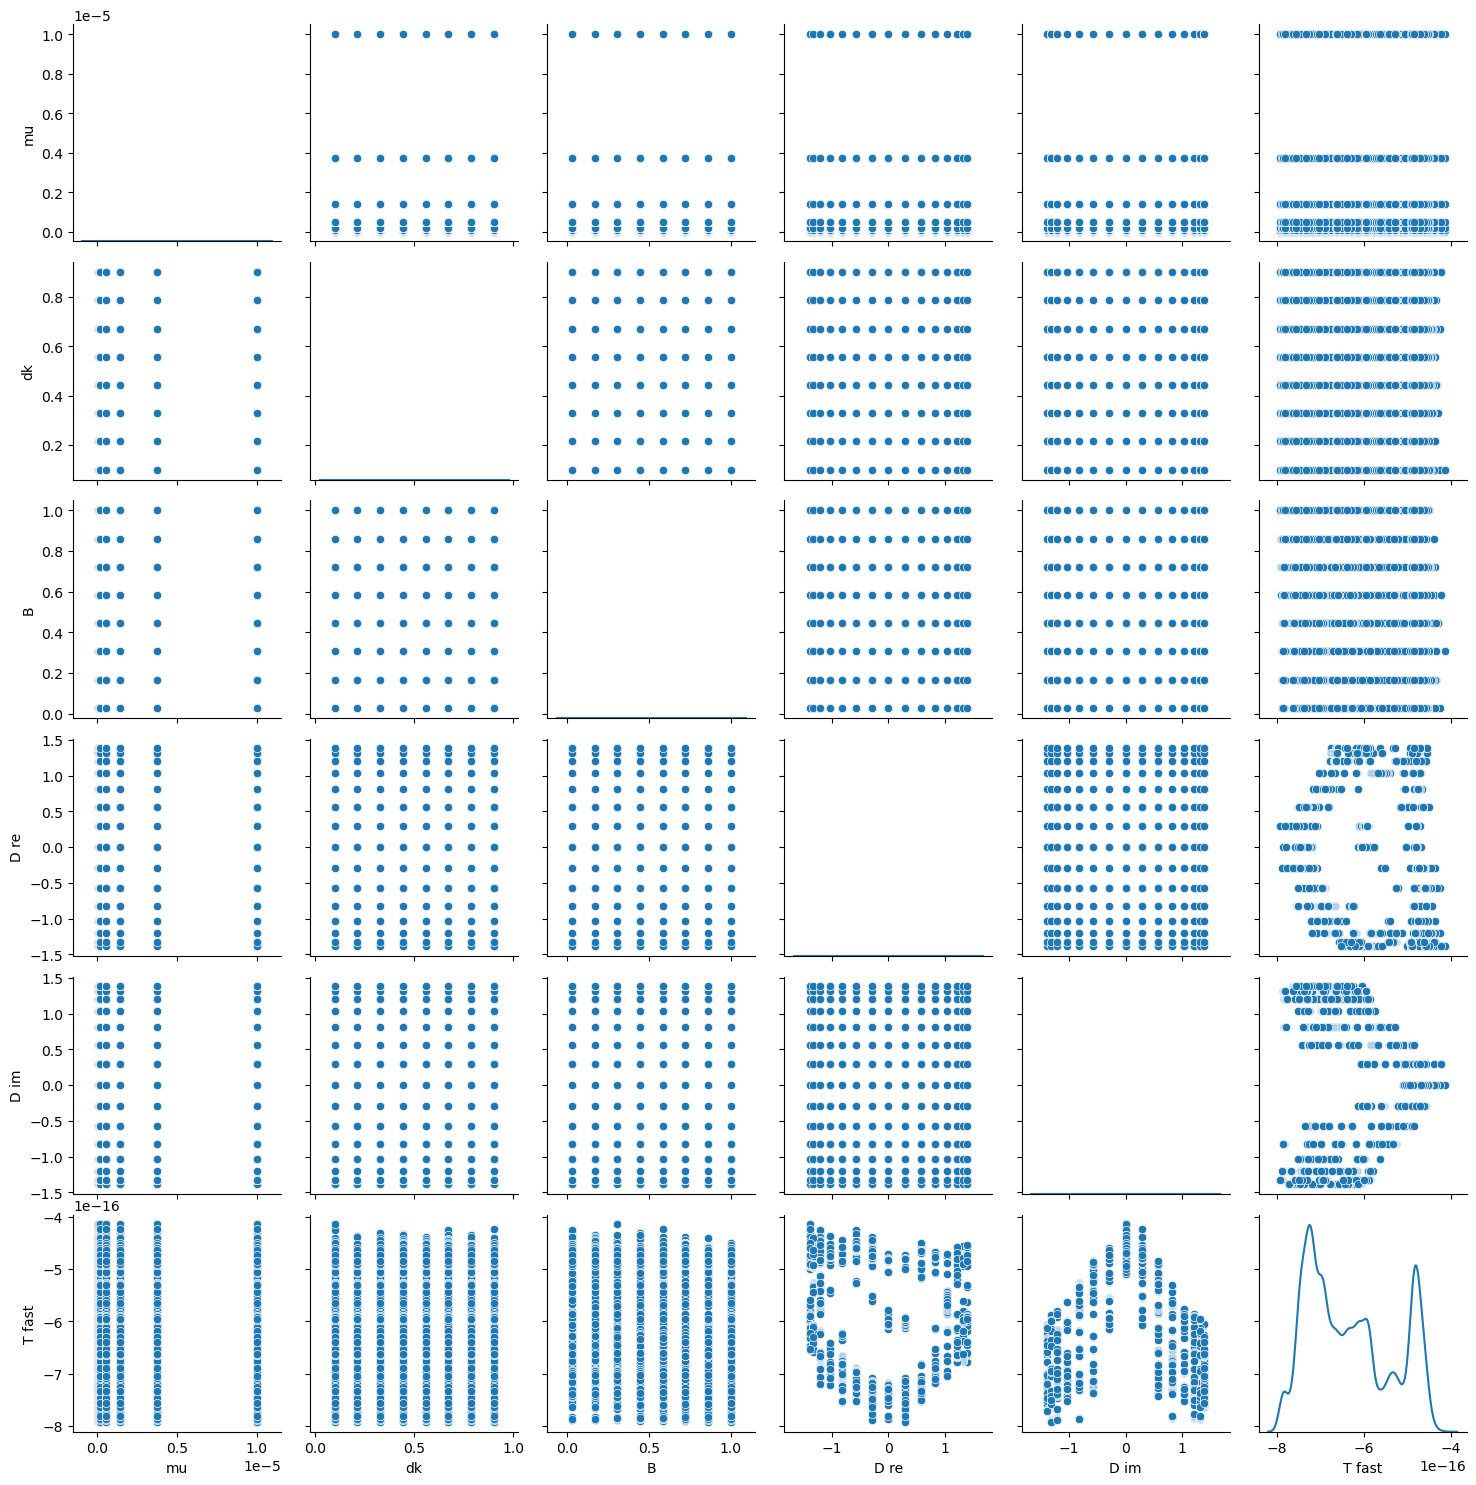

In [23]:
g = sns.PairGrid(dfa)
#g.map(sns.scatterplot)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
#g.map_diag(sns.kdeplot)

In [25]:
t_pred = np.zeros((n_m, n_dk, n_b, n_g, n_g))

for mm in range(n_m): 
    for kk in range(n_dk):
        for nn in range (n_b):
            for ii in range(n_g):
                for jj in range(n_g):
                    # constant terms -- t_0 and intercept (error)
                    t_pred[mm,kk,nn,ii,jj] = pi /(eelib.kFAu+dk_g[kk]/1e-6/2.0) + consts['intercept']
                    # terms independent of mu (error)
                    t_pred[mm,kk,nn,ii,jj] += (np.real(dgridk[kk,ii,jj])**2 * consts['DR2'] 
                                             + np.imag(dgridk[kk,ii,jj])**2 * consts['DI2'] 
                                             + np.imag(dgridk[kk,ii,jj])**4 * consts['DI4'])

In [26]:
size = np.shape(fot.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

sz = [n_dk*n_b*n_g**2, n_b*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ik in range(n_dk):
        for ib in range(n_b):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz[0]+ik*sz[1]+ib*sz[2]+idr*sz[3]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 1] = dk_g[ik]
                    npaf[ind, 2] = B_g[ib]
                    npaf[ind, 3] = np.real(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 4] = np.imag(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 5] = fot0[imu, ik, ib, idr, idi]-t_pred[imu, ik, ib, idr, idi]

115200


In [27]:
dfa = pd.DataFrame(npaf, columns = ["mu", "dk", "B", "D re", "D im", "T fast"])

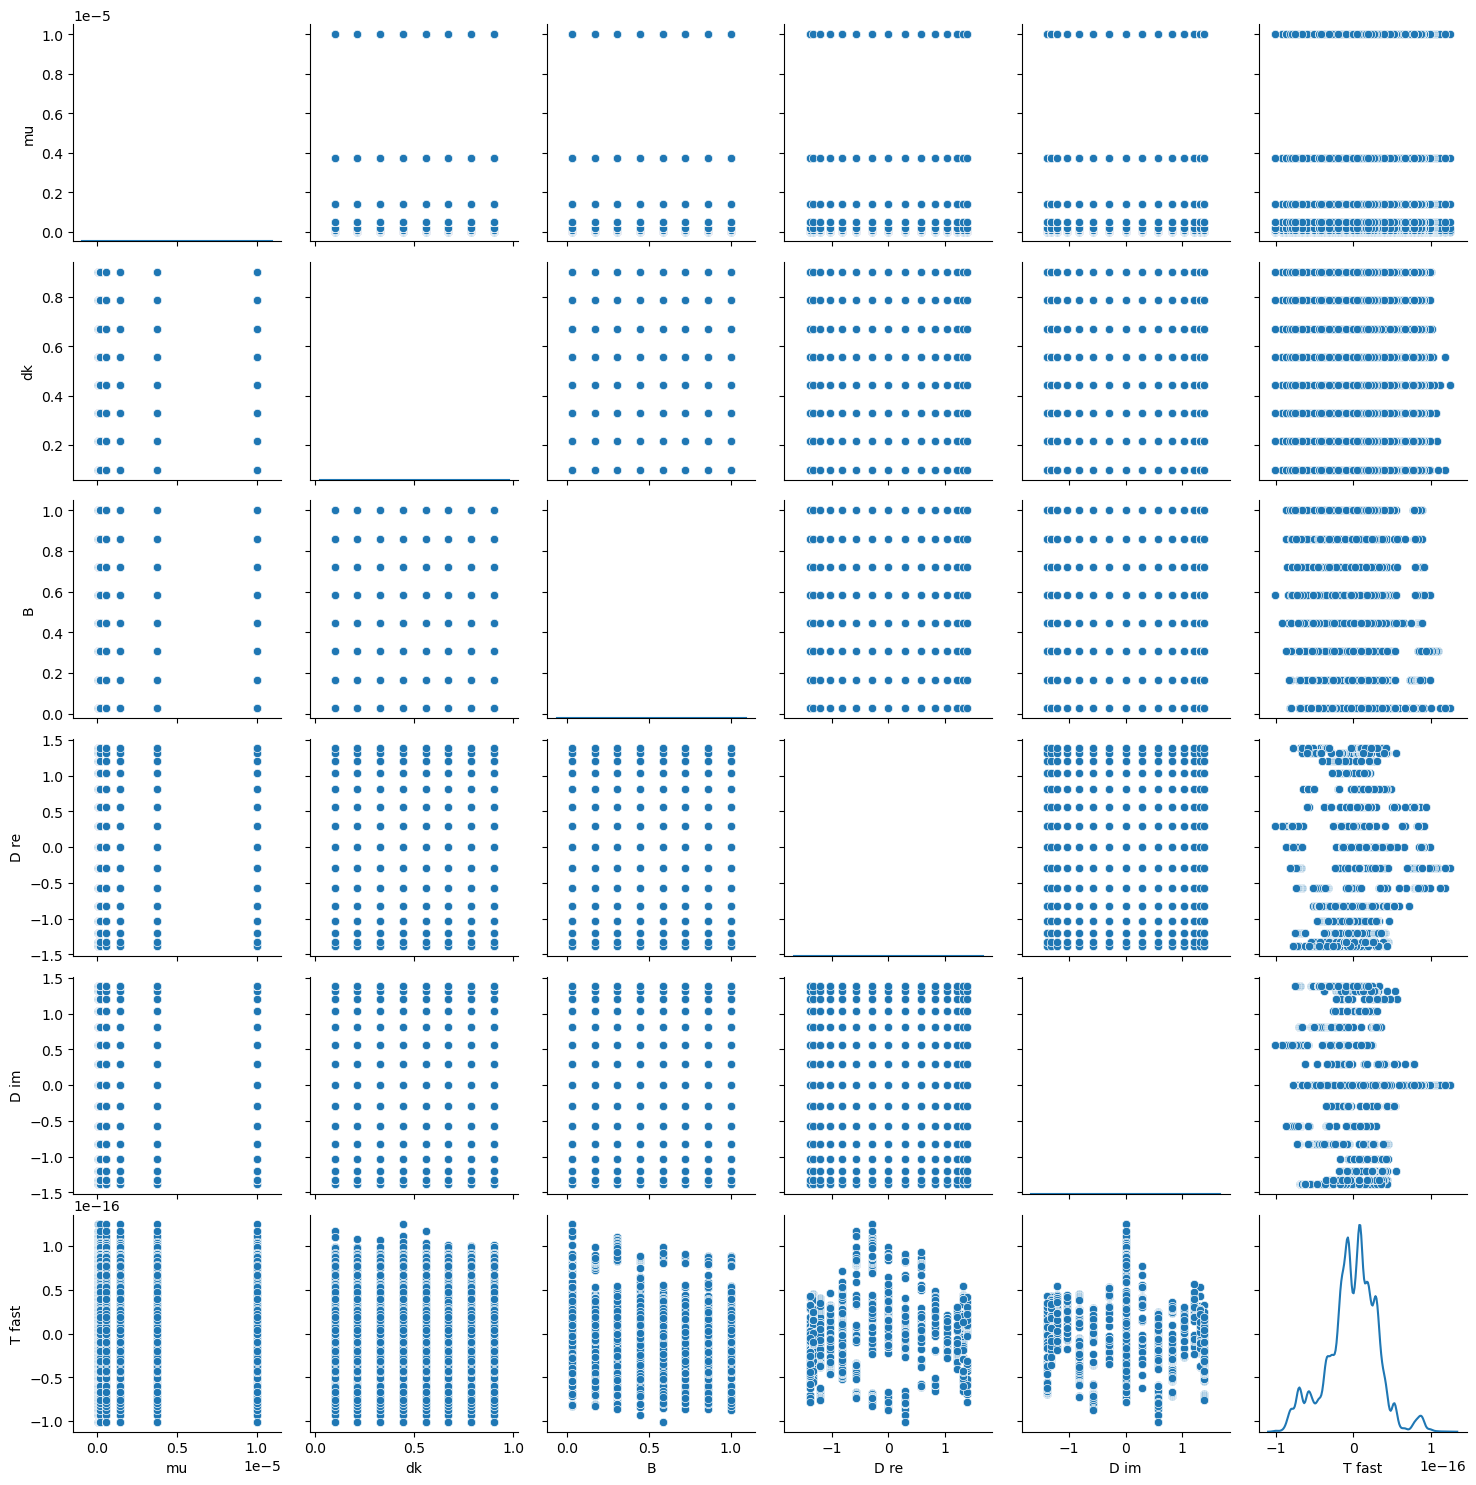

In [28]:
g = sns.PairGrid(dfa)
#g.map(sns.scatterplot)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
#g.map_diag(sns.kdeplot)

The error doesn't quite have the same dependence, but looks the same. I see a difference for $\Im(\Psi^\prime) = 0$. The difference is most likely irrelevant. I should test this on the D grid to see if the error is small enough. 

# $\mu B \Im(\Psi^\prime_0)$ term

In [273]:
dfa.head()

,mu,dk,B,D re,D im,T fast
0,1.000000e-08,0.1,0.03,-1.380810,-1.38081,6.118232e-19
1,1.000000e-08,0.1,0.03,-1.321546,-1.38081,-7.102350e-18
2,1.000000e-08,0.1,0.03,-1.204153,-1.38081,-6.854996e-17
3,1.000000e-08,0.1,0.03,-1.033794,-1.38081,-3.989327e-17
4,1.000000e-08,0.1,0.03,-0.817964,-1.38081,-4.591820e-17


In [275]:
X = np.array([npaf[:,0]*npaf[:,2]*npaf[:,4]]).T

y = npaf[:,5]

reg = LinearRegression(fit_intercept=False).fit(X, y)

slope_mbi=reg.coef_
intercept_mbi=reg.intercept_

r = reg.score(X, y)

print(slope_mbi, intercept_mbi, r)
    

[8.8819135e-10] 0.0 0.9996664454493913


In [277]:
npaf[:,5] = npaf[:,5]-npaf[:,0]*npaf[:,2]*npaf[:,4]*slope_mbi

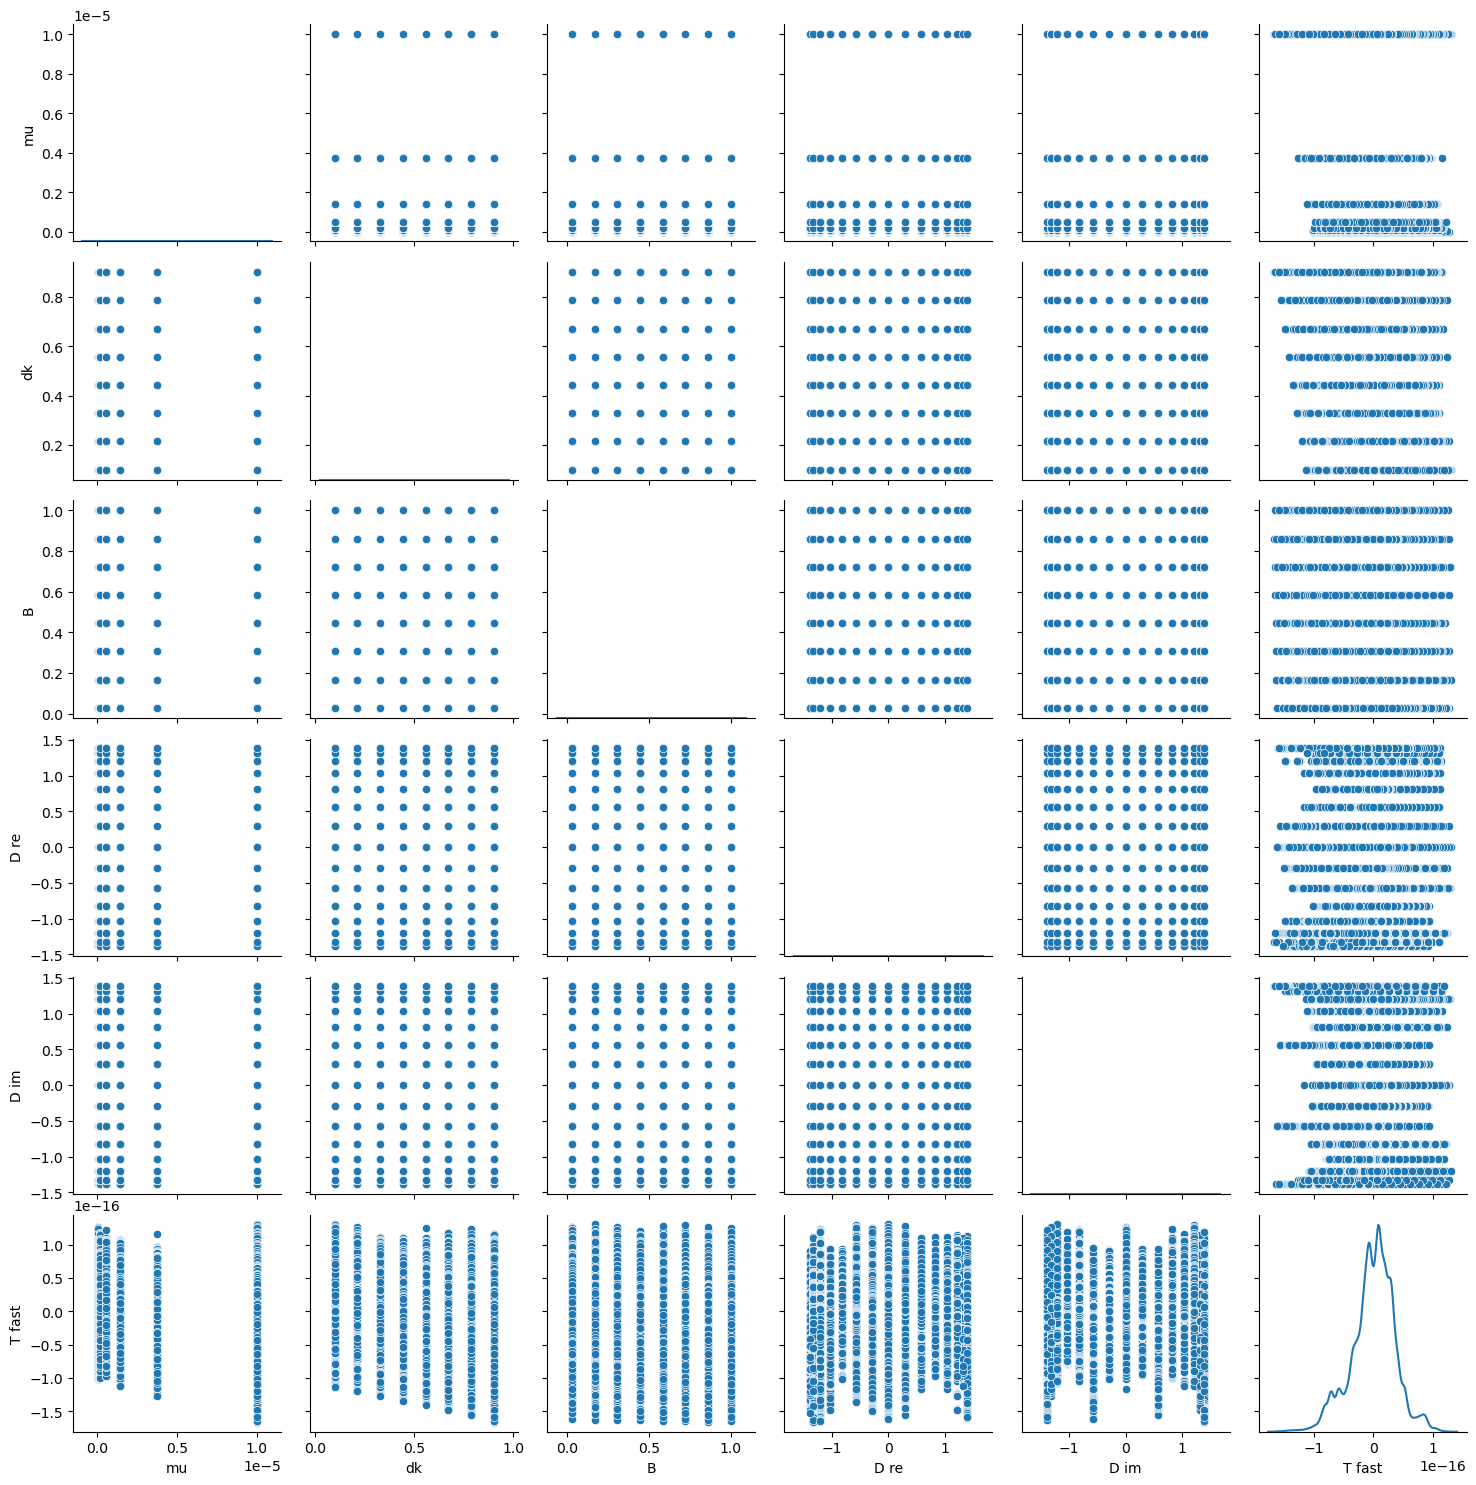

In [278]:
g = sns.PairGrid(dfa)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)

In [279]:
np.max(npaf[:,5]), np.min(npaf[:,5])

(1.3049494444295748e-16, -1.6579712425870837e-16)

Works well. Now I need to test this on other data. 

In [283]:
consts["mBDI"] = slope_mbi[0]

In [284]:
consts

{'mA2': 3.675494115574291e-08,
 'mDIM': -9.499875618824391e-10,
 'mDI2': 3.674200444430406e-08,
 'mDR2': 3.674365054354659e-08,
 'm2': 8.522223583430349e-06,
 'm2DI2': 2.0556114758548036e-05,
 'm2DR2': 2.9358597545134476e-05,
 'm2DR4': 1.598207117609667e-05,
 'm2DI4': 1.5910577914323505e-05,
 'm2DI2R2': 3.182358695140475e-05,
 'intercept': -5.697364648383741e-16,
 'DI2': -2.7618261397447087e-16,
 'DR2': 8.0960114314636e-17,
 'DI4': 9.19298181818588e-17,
 'mBDI': 8.881913496260701e-10}

In [300]:
import json

# writing dictionary to a file as JSON
with open('consts.json', 'w') as f:
    json.dump(consts, f)

I have a mBDI term already. It must not be correct. I may have tried to scale it by $R$, but now I think that the term is better, and I can deal with adding $R$ scaling later.
... No. It is just not correct. Wrong sign, same absolute value. Sign errors are understandable if I subtracted rather than added. 

I can do better by adding $k_0$ to the variables to vary, and testing if this model still works. I think I want Monte Carlo for testing, not the grid.

Remember -- on future runs -- $R$ and $k_0$ are here held constant. Adjust based on new values. I know where $R$ and $k_0$ appear in my model, in principle.

$k_0$ has been run and determined to be too complex for a first analysis. This work will be put aside for now. 

Varying $R$ and $A_0$ appear to cause a growth in error. I already know that, but recieved conformation. However, I know that keeping them fixed and rescaling other variables in the code is a possibility. $R$ rescales $B$ and $t_{fin}$, while $A_0$ rescales $\mu$ and alters $\Psi^\prime$ in an unknown fashion. Since $\Psi^\prime$ is fit for, and just an intermediate, it is easier to just ignore this, as rescaling $\Psi^\prime$ is unnecessary. We work with $\Psi^\prime$ defined for $A_0 = 1$, and we know the final results will be identical to the rescaled version, despite not knowing $\Psi^\prime$ within the rescaled version.

We have a beautiful model of a weakly non-linear system, despite solving for a time-independent case. Solinoids will not emerge, of course, since we removed that possibility at the beginning, but that doesn't prevent certain interesting aspects of non-linear dynamics from occuring.

I believe the last on the list before $M$ runs will be separating out which of the correction come from linear error and which corrections come from non-linearity. My assumption is that non-linear error is of much lower order, and doesn't appear. While I have good reason to believe this is the case if it is not true, it invalidates my results. Testing this particular hypothesis will be quite difficult.

I also need to put both timings into my old derivitive grid plots, to see if they are correct.

As far as I can tell, the drop in power is related to a systematic underestimation of the period, which exists even for the linear case. The power drop appears near-indentical within both cases, and there exists a correction to the period independent of $\mu$ with partial chaotic dependence on other parameters. When the terms line up properly, the error is at the error seen, but when they don't, the error is much larger. Interpolation is relatively safe, so we can just avoid the values which don't line up properly. 

In [296]:
consts['mDIM']= consts['mDIM'] + consts['mBDI']

In [297]:
consts['mBDI'] = 0

# Old Model